# West Gardar lamprophyre dykes ca. 1271 Ma paleomagnetic pole

## Geologic context

The West Gardar lamprophyre dykes belong to the Gardar igneous province of South
Greenland, an intracontinental alkaline rift province. Piper & Stearn (1977)
sampled the Gardar dyke swarms and reported site-mean directions; the
lamprophyre dykes carry a shallow, northwest-directed magnetization. The dykes
are near-vertical intrusions and require no tilt correction.

## Pole

This notebook recreates the lamprophyre-dyke pole at the dyke level as the Fisher
mean of the 9 site virtual geomagnetic poles (VGPs) of Piper & Stearn
(1977). The site table archives directions only (no per-site coordinates), so VGPs
are computed at the sampling locality (61.2 deg N, 311.7 deg E). As a
Laurentia-Greenland pole it is shown rotated into the Laurentia reference frame
(using the Greenland Euler pole of `pole_tools`) in the APWP-context and
pole-overlap plots.

## Age constraints

- Nominal age 1271 Ma (bounds 1263-1278 Ma). Piper & Stearn (1977) cite Patchett &
  Upton (1977) -- a study that was never published -- for Rb-Sr biotite ages of
  1278, 1277, 1272, 1265, and 1263 Ma on the Gardar dolerite dykes. These are
  adopted as the age bounds, with their average (1271 Ma) as the nominal age.
  Because the only control is unpublished Rb-Sr biotite cooling ages, the age is
  poorly constrained.

## References

- Paleomagnetic source and age constraint: Piper, J. D. A., & Stearn, J. E. F. (1977). Palaeomagnetism of the dyke swarms of the
  Gardar igneous province, south Greenland. *Physics of the Earth and Planetary
  Interiors*, 14(4), 345-358. https://doi.org/10.1016/0031-9201(77)90167-4

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Loaded from `../data/1238_West_Gardar_lamprophyre/`. The contribution stores site-mean directions
only (Piper & Stearn, 1977), so a virtual geomagnetic pole is computed for each
dyke at the common sampling locality (61.2 deg N, 311.7 deg E) with
`pmag.dia_vgp`.

In [2]:
sites = pd.read_csv('../data/1238_West_Gardar_lamprophyre/sites.txt', sep='\t', skiprows=1)
dyke = sites[sites['result_quality'] == 'g'].reset_index(drop=True)
study_lat, study_lon = 61.2, 311.7

# directions only in the contribution -> compute each dyke's VGP at the locality
vgp_lon, vgp_lat = [], []
for _, r in dyke.iterrows():
    a95 = r['dir_alpha95'] if pd.notna(r['dir_alpha95']) else 5.0
    plon, plat, dp, dm = pmag.dia_vgp(r['dir_dec'], r['dir_inc'], a95, study_lat, study_lon)
    vgp_lon.append(round(plon, 1)); vgp_lat.append(round(plat, 1))
dyke = dyke.assign(vgp_lon=vgp_lon, vgp_lat=vgp_lat)
print(f'{len(dyke)} lamprophyre dykes')
dyke[['site', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

9 lamprophyre dykes


,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,8,279.4,-0.1,94,7.0,6,4.5,213.4
1,16,283.7,17.3,42,10.4,6,14.3,213.9
2,19,284.8,1.7,147,5.6,6,7.8,209.1
3,23,286.8,-23.1,203,4.7,6,-2.7,201.3
4,25,288.8,-24.5,107,2.3,5,-2.5,199.2
5,26,287.0,-21.4,895,2.2,6,-1.7,201.6
6,29,288.9,-7.2,40,10.7,6,5.8,203.3
7,31,286.7,-22.7,103,6.7,6,-2.5,201.5
8,41,278.3,3.2,90,9.4,4,5.4,215.2


## Mean pole from site VGPs

The directions form a single, near-horizontal northwest-directed cluster (shallow,
low paleolatitude), so the mean direction is computed without polarity
unification. Because the inclinations straddle the horizontal, the corresponding
site VGPs fall into two near-antipodal groups; the pole is therefore the Fisher
mean of the VGPs after uniting their polarity.

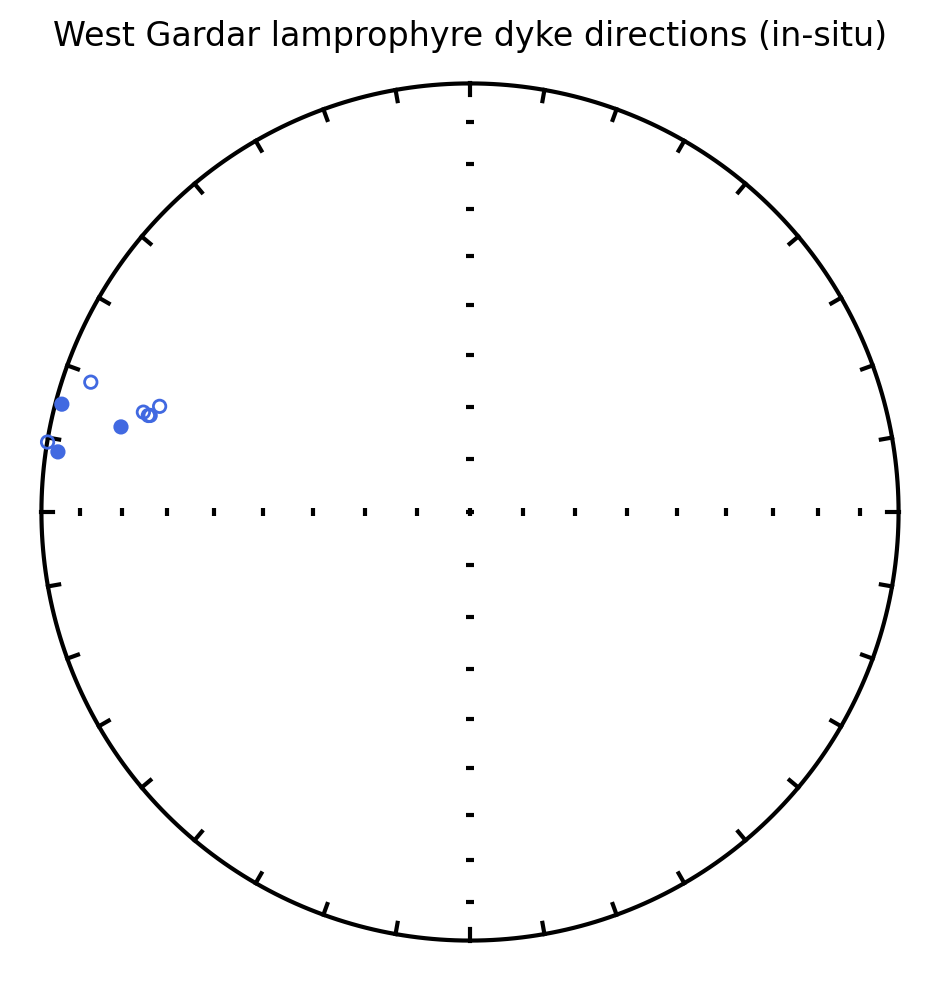

Plon: 206.5  Plat: 3.2
Number of directions in mean (n): 9
Angular radius of 95% confidence (A_95): 5.5
Precision parameter (k) estimate: 87.2

Piper & Stearn (1977) / prior compilation pole: 3.2 N / 206.4 E, A95 7.2


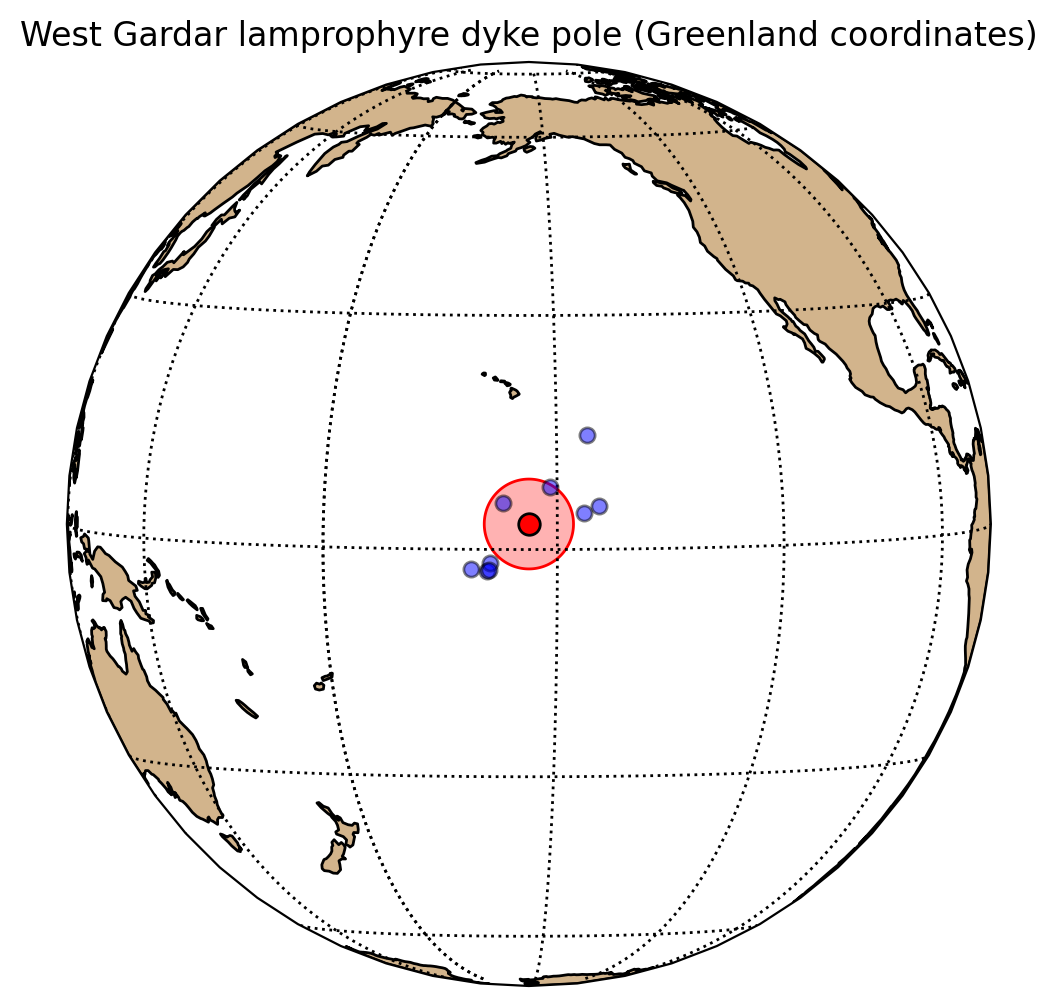

In [3]:
ipmag.plot_net()
ipmag.plot_di(dyke['dir_dec'].tolist(), dyke['dir_inc'].tolist(), color='royalblue', marker='o')
plt.title('West Gardar lamprophyre dyke directions (in-situ)')
plt.show()

vgp_block, pole_mean = pt.compute_mean_pole(dyke, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nPiper & Stearn (1977) / prior compilation pole: 3.2 N / 206.4 E, A95 7.2')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('West Gardar lamprophyre dyke pole (Greenland coordinates)')
plt.show()

## Mean direction

Dec: 284.8  Inc: -8.6
Number of directions in mean (n): 9
Angular radius of 95% confidence (a_95): 10.0
Precision parameter (k) estimate: 27.5
Piper & Stearn (1977) mean direction: 284.8/-8.6


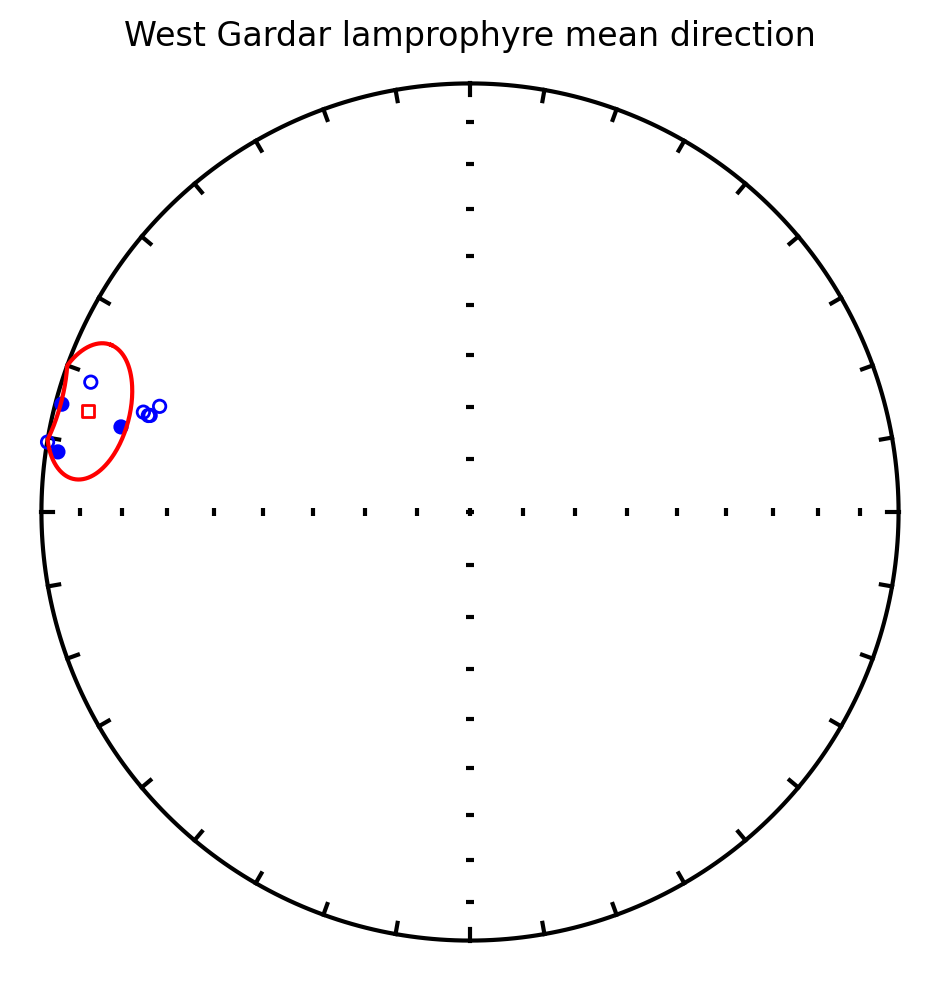

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(dyke, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)
print('Piper & Stearn (1977) mean direction: 284.8/-8.6')
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.title('West Gardar lamprophyre mean direction')
plt.show()

## Paleosecular variation

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: no
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: no
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 51 samples (>= 25): PASS
        K = 87.2 (10-70): FAIL
        B = 9 sites (>= 8): PASS
        min 4 samples/site (>= 3): PASS
        A95 = 5.5 in Deenen envelope [5.0, 20.5]: PASS
  => R2 (from sub-criterion c) = 0

A_95 of 5.5 passes Deenen et al. (2011) criteria of being between 5.0 and 20.5 for this number of sites


<Axes: title={'center': 'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

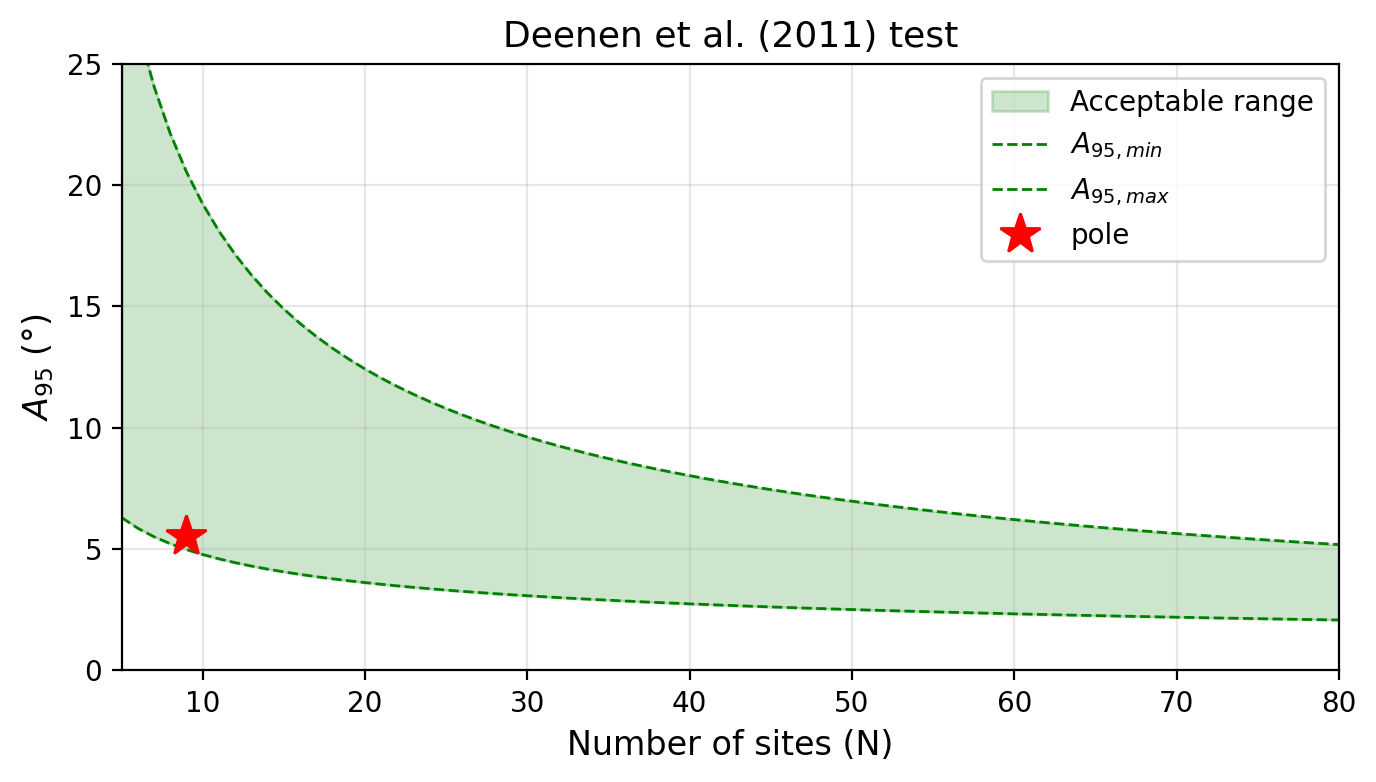

In [5]:
r2 = pt.assess_R2(dyke, pole_mean)
print()
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are Fisher
distributed, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD model expectation at the sampling
paleolatitude.

In [6]:
fishqq_result = pt.fishqq_vgps(dyke, unify_polarity=True)
fishqq_result

you need N> 10 for at least one mode


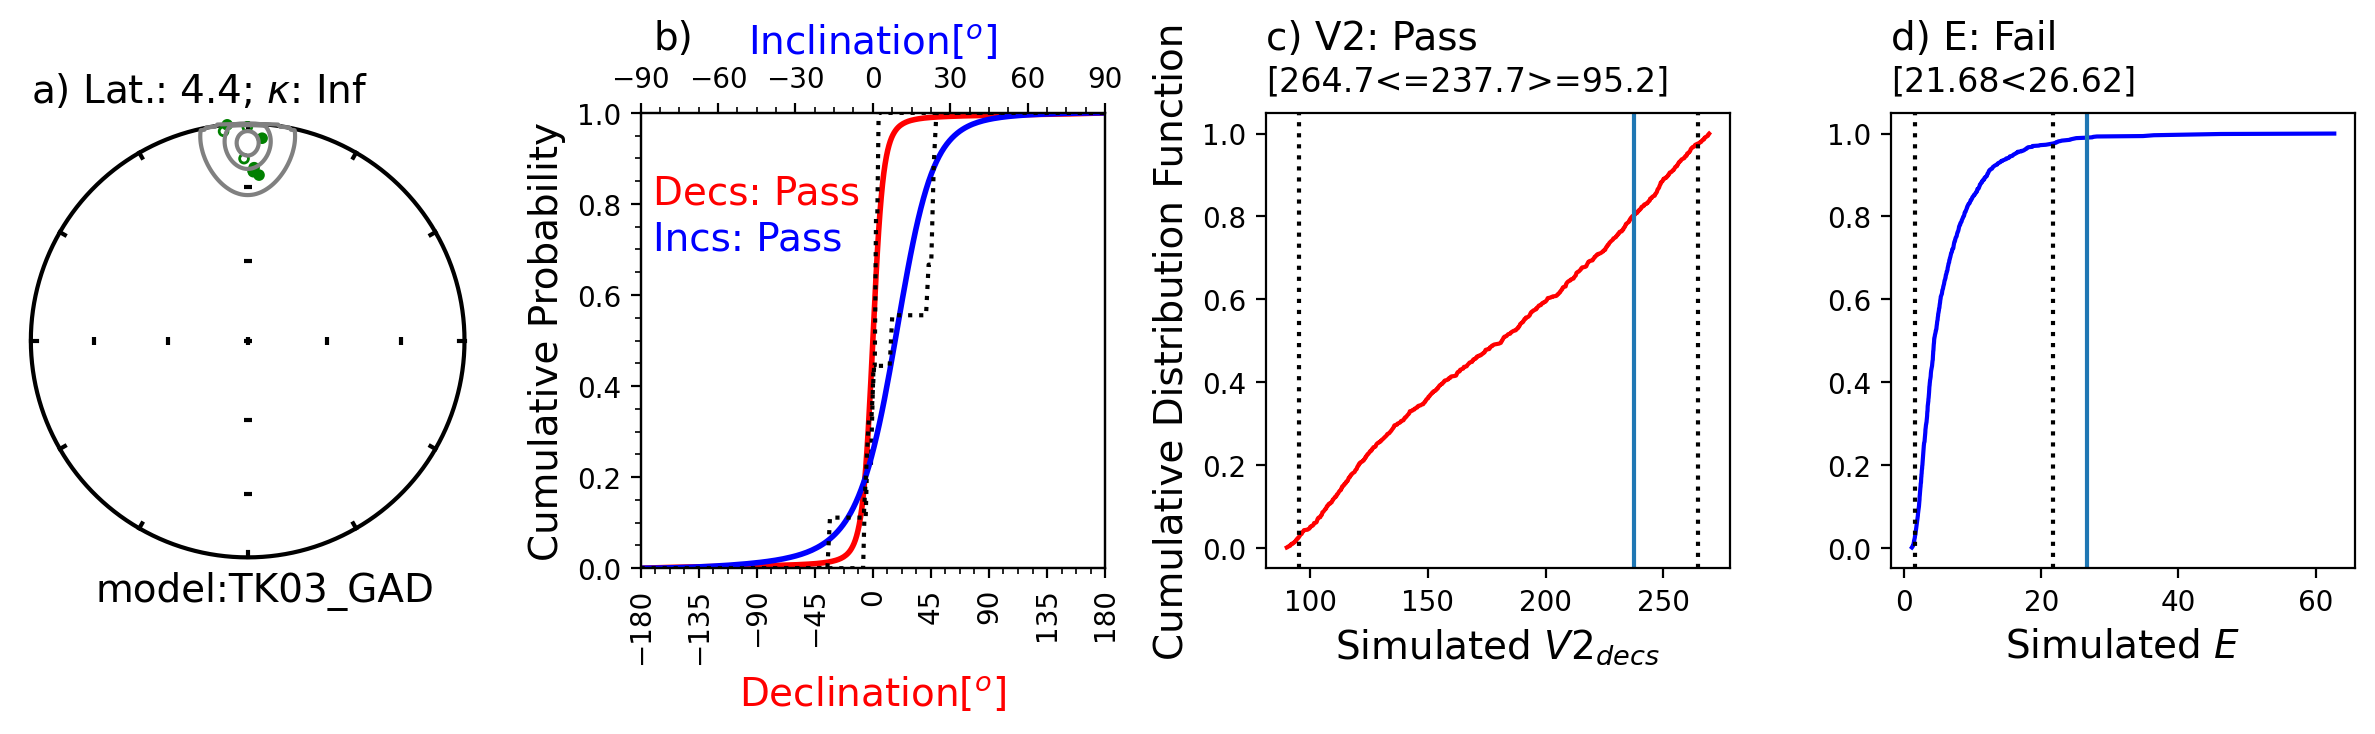

paleolatitude = 4.4 deg; elongation E = 26.62 (inconsistent with TK03.GAD)


In [7]:
try:
    svei_result = pt.svei_test_vgps(dyke, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(dyke, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

With only nine dykes the Fisher Q-Q test cannot be evaluated (it requires N > 10 in a mode), and the directional distribution is strongly elongated relative to the TK03.GAD expectation (E ~ 27, inconsistent), reflecting the small, over-clustered, shallow VGP set.

## The West Gardar pole in the context of the Laurentia APWP

As a Laurentia-Greenland pole it is rotated into the Laurentia reference frame with the Greenland Euler pole used by `pole_tools.get_Laurentia_poles`.

pole in Laurentia frame: 6.6 N / 194.0 E, A95 5.5


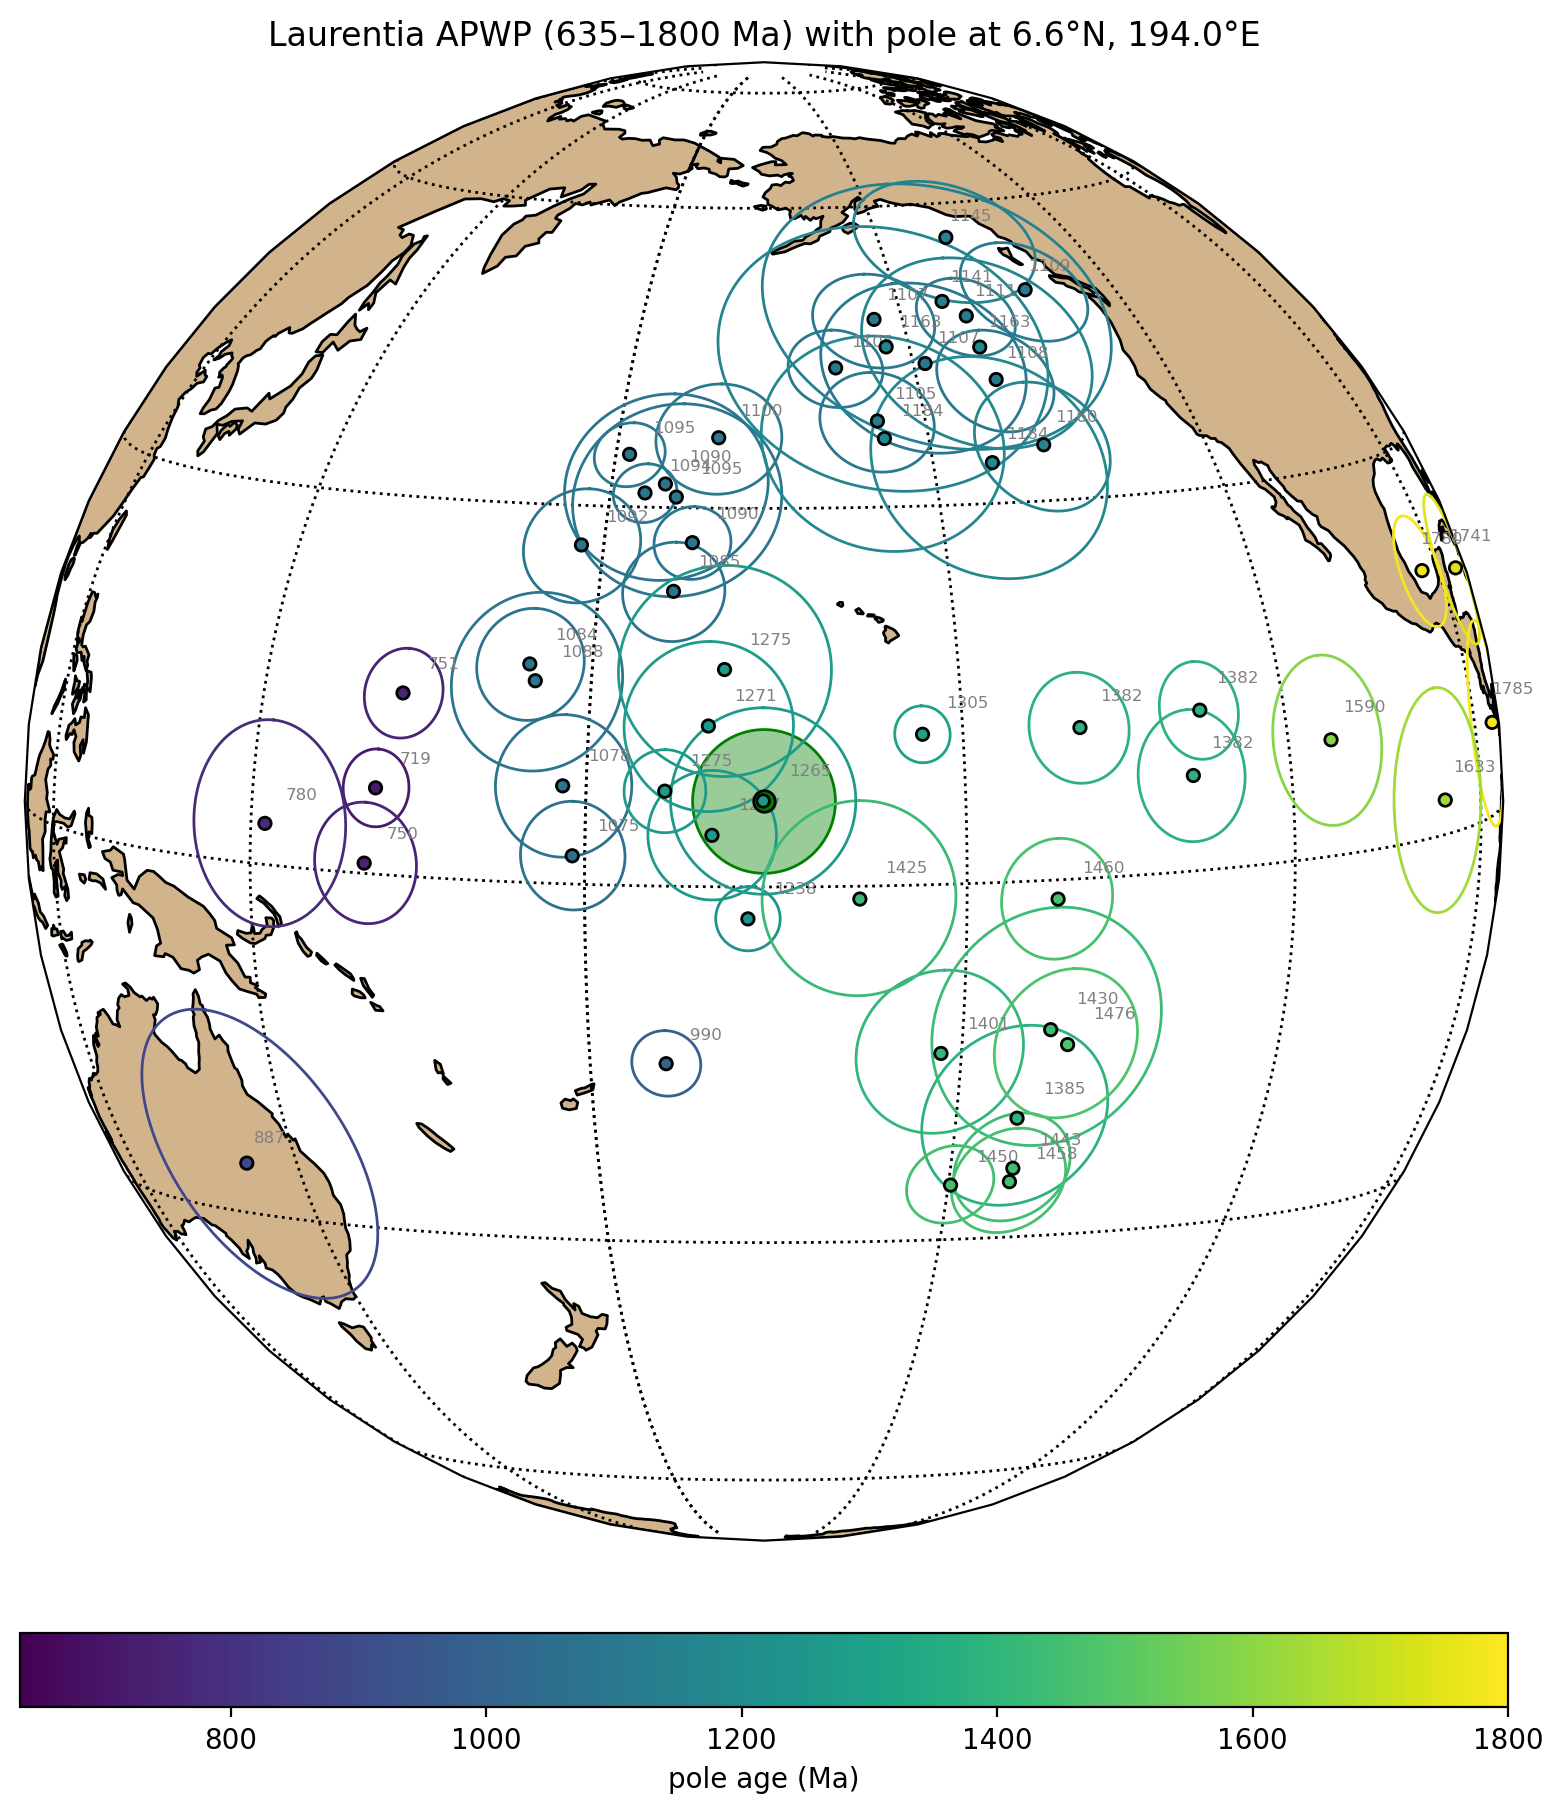

In [8]:
# rotate the Greenland-coordinate pole into the Laurentia reference frame
EULER_GREENLAND = pt.TERRANE_EULER_POLES['Laurentia-Greenland']   # [67.5, -118.5, -13.8]; Roest & Srivastava (1989)
_rlat, _rlon = pmag.pt_rot(EULER_GREENLAND, [pole_mean['inc']], [pole_mean['dec']])
pole_rot = {'inc': _rlat[0], 'dec': _rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"pole in Laurentia frame: {pole_rot['inc']:.1f} N / {pole_rot['dec']:.1f} E, A95 {pole_rot['alpha95']:.1f}")

Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_rot['inc'], pole_rot['dec'],
                          pole_rot['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rot['dec'],
                          central_latitude=pole_rot['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

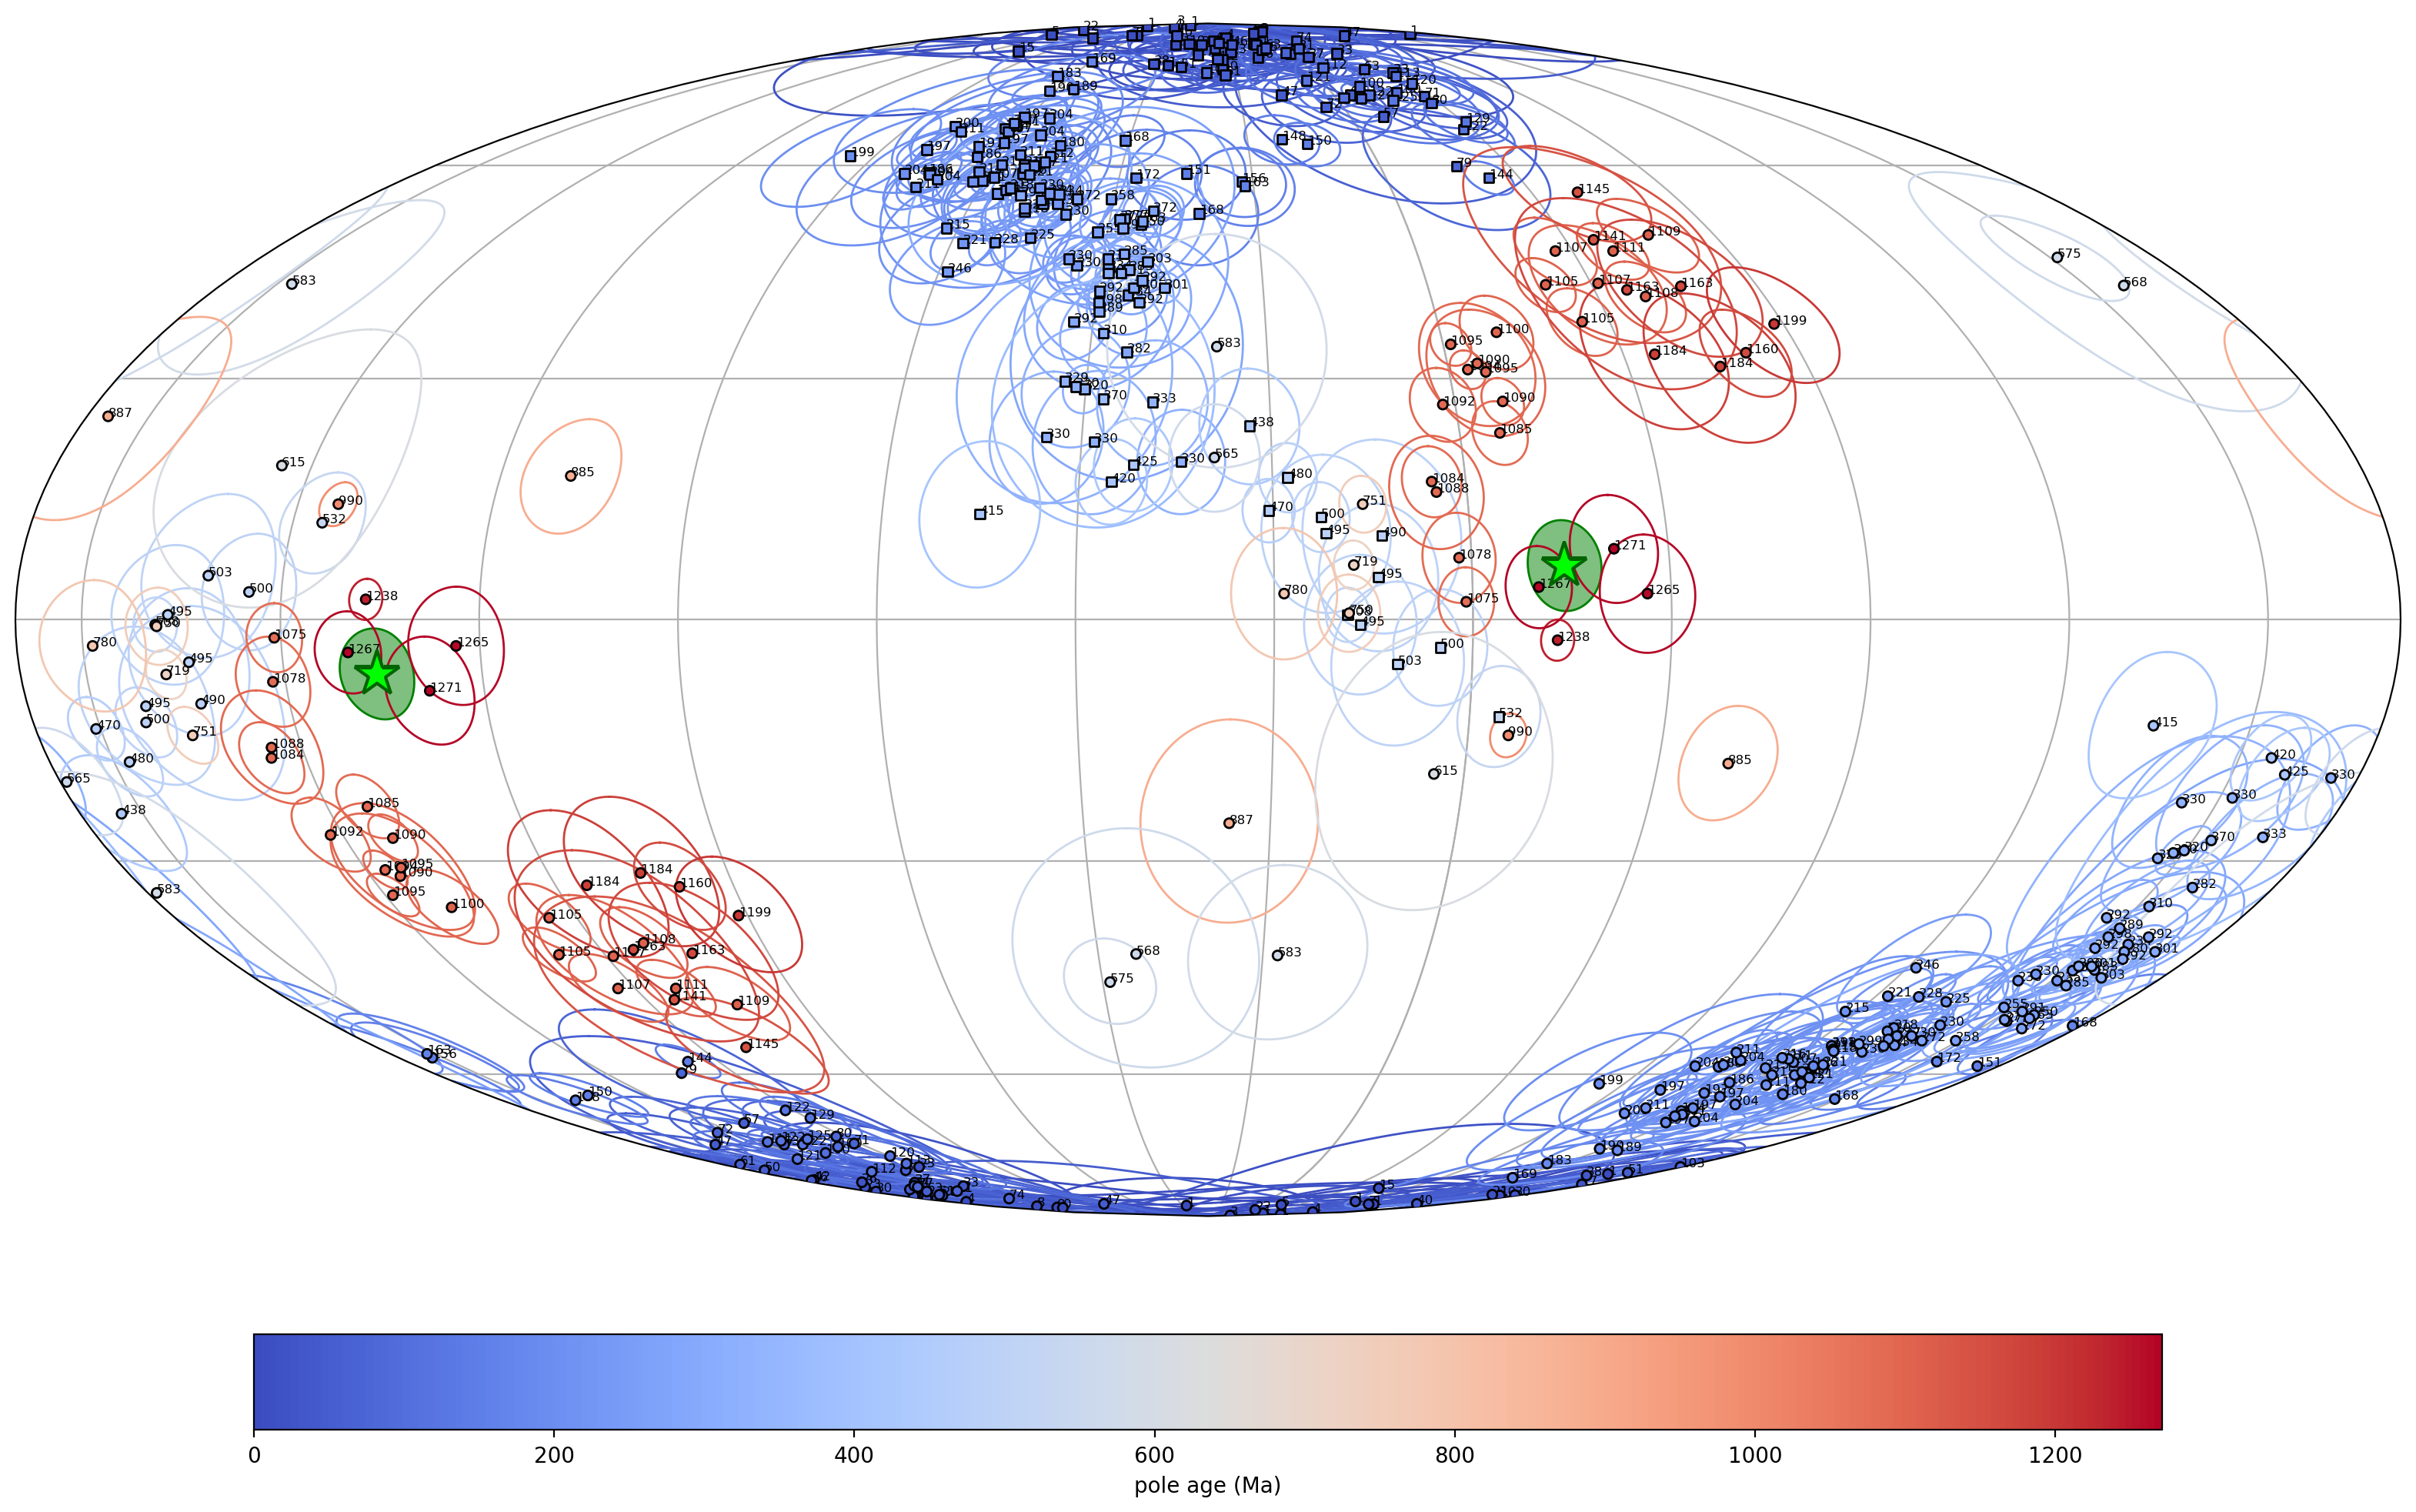

<GeoAxes: >

In [9]:
Laurentia_poles = pt.get_Laurentia_poles()
pt.plot_pole_overlap('West Gardar Lamprophyre Dykes', Laurentia_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rot['inc'], pole_plon=pole_rot['dec'],
                     pole_A95=pole_rot['alpha95'], pole_age=1271)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **0** | The only age control is unpublished Rb-Sr biotite cooling ages (1263-1278 Ma) attributed to Patchett & Upton (1977); no reliable published radiometric date. |
| 2 | Techniques and statistical analysis | **0** | Sub-criterion (c) is not met: although N = 51 samples, B = 9 sites, and A95 = 5.5 deg pass, the VGP precision K = 87 exceeds 70 and the distribution is over-clustered and non-Fisherian for only nine dykes, indicating that paleosecular variation is undersampled. R2 = 0 (consistent with the prior compilation). |
| 3 | Magnetic mineralogy characterized | **1** | Remanence carried by magnetite, characterized by alternating-field demagnetization (Piper & Stearn, 1977). |
| 4 | Field tests constrain age of magnetization | **0** | No field tests were reported (Piper & Stearn, 1977). |
| 5 | Structural control / tectonic coherence | **0** | Greenland (Gardar province); the prior compilation did not credit structural/tectonic coherence with the Laurentian craton. |
| 6 | Presence of reversals | **0** | A single, shallow northwest-directed polarity; no reversal test. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **2/7** | Grade B |

## Nordic workshop summary

The West Gardar lamprophyre pole is recreated as the Fisher mean of the
9 site VGPs of Piper & Stearn (1977) (computed at the sampling
locality), reproducing the prior-compilation pole (3.2 N / 206.4 E, A95 7.2). The Greenland
pole is reported in its present (Greenland) coordinates in the summary and shown
rotated into the Laurentia frame in the plots above. The age rests on unpublished
Rb-Sr biotite cooling ages (1263-1278 Ma), giving a Grade B, R = 2 pole.

### West Gardar lamprophyre dyke pole

| | This study (site VGPs) | Piper (1977) | Previous Nordic compilation |
|---|---|---|---|
| Component | ChRM, site-VGP mean | Group mean (direction → pole) | Primary ChRM |
| N (sites) | 9 | 9 | 9 |
| N (specimens) | 51 | 51 | 51 |
| Dec (°) | 284.8 | 284.8 | 284.8 |
| Inc (°) | −8.6 | −8.6 | −8.6 |
| k (direction) | 27.5 | 28 | 28.0 |
| α95 (direction, °) | 10.0 | 10.0 | 10.0 |
| Pole lat (°N) | 3.2 | 3.2 | 3.2 |
| Pole lon (°E) | 206.5 | 206.4 | 206.4 |
| A95 (pole, °) | 5.5 | — | 7.2 |
| dp / dm (°) | — | 5.1 / 10.1 | 5.1 / 10.1 |

Piper (1977), Table I "Group mean directions and poles": lamprophyre dykes, D = 284.8°, I = −8.6° (α95 = 10.0°, k = 28, N = 9 dykes / 51 samples), pole 3.2°N / 206.4°E (dp/dm = 5.1°/10.1°). Previous Nordic compilation: Evans et al. (2021), `data/Evans_et_al_2021_compilation.csv`. Poles are in present-day (Greenland) coordinates; the Euler rotation into the Laurentia frame is applied separately for the APWP comparison above. The tighter "This study" A95 (5.5°) is the circular VGP-Fisher confidence, vs the elongated direction→pole dp/dm oval (dm = 10.1°; geometric-mean A95 7.2° in the compilation).

In [10]:
wg_summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='West Gardar Lamprophyre Dykes',
    sites=dyke,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='ChRM (magnetite); single shallow northwest-directed polarity',
    tests='',
    gpmdb_number='2108',
    percent_reversed=0,
    demag_code=3,
    R1=0,
    R2=0,
    R3=1,
    R4='',
    R5=0,
    R6=0,
    R7=1,
    Grade='B',
    nominal_age=1271,
    lomagage=1263,
    himagage=1278,
    REF_method="- Nominal age 1271 Ma (bounds 1263-1278 Ma). Piper & Stearn (1977) cite Patchett &\n  Upton (1977) -- a study that was never published -- for Rb-Sr biotite ages of\n  1278, 1277, 1272, 1265, and 1263 Ma on the Gardar dolerite dykes. These are\n  adopted as the age bounds, with their average (1271 Ma) as the nominal age.\n  Because the only control is unpublished Rb-Sr biotite cooling ages, the age is\n  poorly constrained.",
    POLE_AUTHORS='Piper, J. D. A., & Stearn, J. E. F.',
    YEAR=1977,
    JOURNAL='Physics of the Earth and Planetary Interiors',
    VOLUME='14',
    VPAGES='345-358',
    TITLE='Palaeomagnetism of the dyke swarms of the Gardar igneous province, south Greenland',
    COMMENT='West Gardar lamprophyre pole recreated as the Fisher mean of the 9 site VGPs of Piper & Stearn (1977), VGPs computed at the sampling locality (61.2N/311.7E); reproduces the prior-compilation pole (3.2 N / 206.4 E, A95 7.2). Directions only in the source; single shallow NW-directed polarity. Pole in Greenland coordinates.'
)
pt.save_nordic_summary(wg_summary, '1271_West_Gardar_lamprophyre')
wg_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,West Gardar Lamprophyre Dykes,GPMDB:2108,ChRM (magnetite); single shallow northwest-dir...,,0,61.2,311.7,9,51,...,1278,- Nominal age 1271 Ma (bounds 1263-1278 Ma). P...,West Gardar Lamprophyre Dykes,"Piper, J. D. A., & Stearn, J. E. F.",1977,Physics of the Earth and Planetary Interiors,14,345-358,Palaeomagnetism of the dyke swarms of the Gard...,West Gardar lamprophyre pole recreated as the ...
